# Предсказание оттока клиентов с использованием методов машинного обучения на основе деревьев

#### Цель: Создать модель предсказания того, уйдет ли абонент в отток (churn).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../DATA/Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Часть 1: Общие характеристики данных

**С помощью метода .info() проверим типы данных для колонок, а также есть ли отсутствующие значения в датафрейме.**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


Отсутствующих значений NaN в датафрейме нет. Большая часть колонок имеют тип данных object, поэтому их надо будет кодировать.

**Выведем статистические метрики для числовых колонок с помощью .describe().**

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Колонка SeniorCitizen принимает значения 0 и 1, остальные численные столбцы содержат непрерывные значения. **Посмотрим на количество уникальных значений в датафрейме:**

In [6]:
df.nunique()

customerID          7032
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

Большинство категориальных переменных принимает либо 2, либо 3 значения. Поэтому матрица, полученная после one hot кодирования будет не намного больше исходной.

# Часть 2:  Исследование данных (Exploratory Data Analysis)

## Исследование признаков

**Убедимся в том, что в этих данных нет отсутствующих значений - для этого выведем количество значений NaN отдельно для каждой колонки.**

In [7]:
df.isnull().sum(axis=0)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Ни одна из колонок не содержит NaN-ов.

**Построим график CountPlot для проверки сбалансированности значений колонки с классами (Churn).**

In [10]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

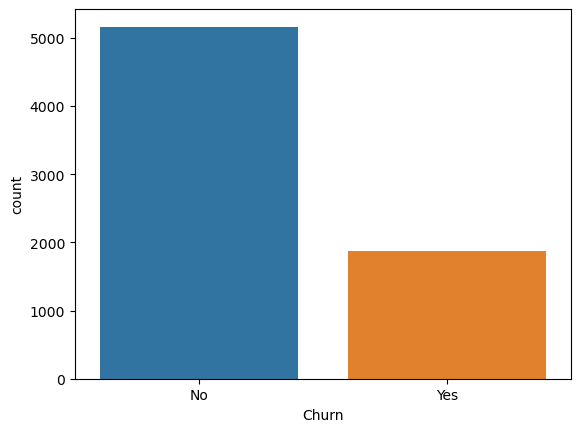

In [9]:
sns.countplot(data=df, x='Churn', hue='Churn');

Целевая переменная (`Churn`) немного несбалансирована: значение 'No' встречается чаще, чем значение 'Yes' в $\approx 2.7$ раз, что не так критично.

**Исследуем распределение колонки TotalCharges (общая сумма платежей) по различным категориям Churn с помощью графика Box Plot и Violin Plot.**

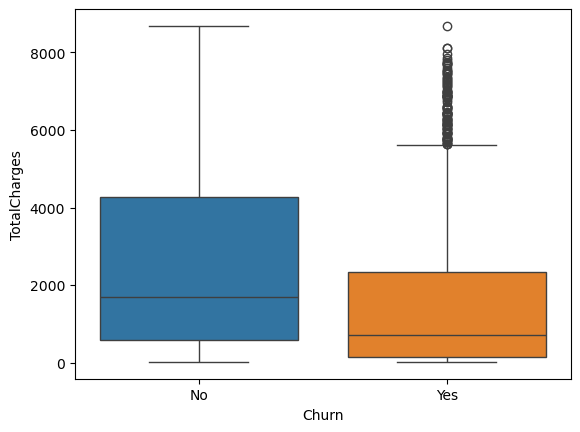

In [12]:
sns.boxplot(data=df, y='TotalCharges', x='Churn', hue='Churn');

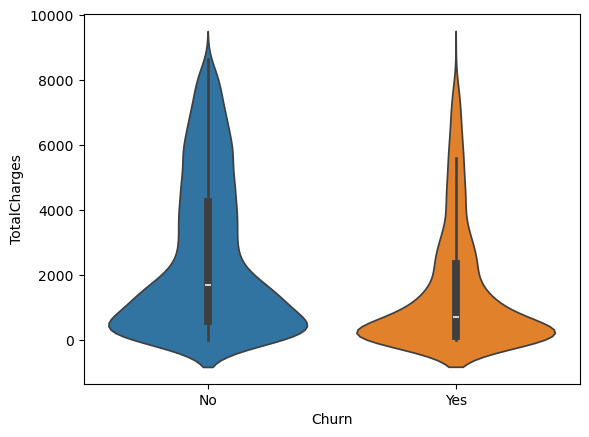

In [13]:
sns.violinplot(data=df, y='TotalCharges', x='Churn', hue='Churn');

Для `Churn='Yes'` медиана меньше, чем для `Churn='No'`, что логично, так как если клиент ушел, то общая сумма его платежей меньше. Значения `TotalCharges > 6000` для `Churn='Yes'` считаются выбросами.

**Построим график boxplot с распределением колонки TotalCharges для различных типов контрактов, а также добавим раскраску цветами по колонке Churn.**

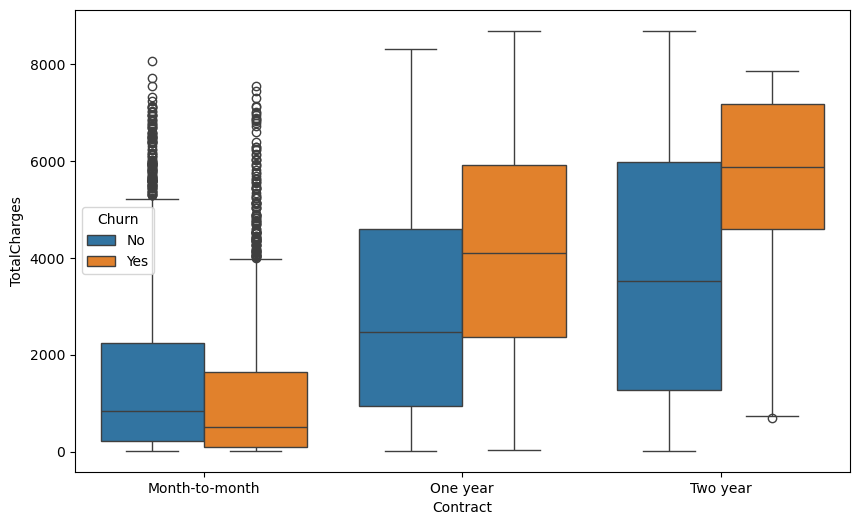

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='TotalCharges', x='Contract', hue='Churn');

У клиентов, у которых тип контракта был помесячный, сумма платежей в среднем была меньше, чем у людей с контрактами на 1 и 2 года. Для однолетних и двухлетних контрактов медиана графика для `Churn = 'Yes'` больше, чем для `Churn = 'No'`. То есть в отток чаще уходят клиенты, которые платят больше.

**Построим график barplot с корреляции указанных ниже признаков с целевой переменной:**

['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

*Проверим только указанные признаки, так как некоторые признаки имеют слишком много уникальных значений для такого анализа, например колонка customerID.*

In [23]:
corr_df = pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
   'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']])
corr_df = corr_df.corrwith(corr_df['Churn_Yes']).sort_values(ascending=True).iloc[1:-1]
corr_df

Contract_Two year                         -0.301552
OnlineSecurity_No internet service        -0.227578
TechSupport_No internet service           -0.227578
InternetService_No                        -0.227578
OnlineBackup_No internet service          -0.227578
StreamingMovies_No internet service       -0.227578
StreamingTV_No internet service           -0.227578
DeviceProtection_No internet service      -0.227578
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
OnlineBackup_Yes                          -0.082307
DeviceProtec

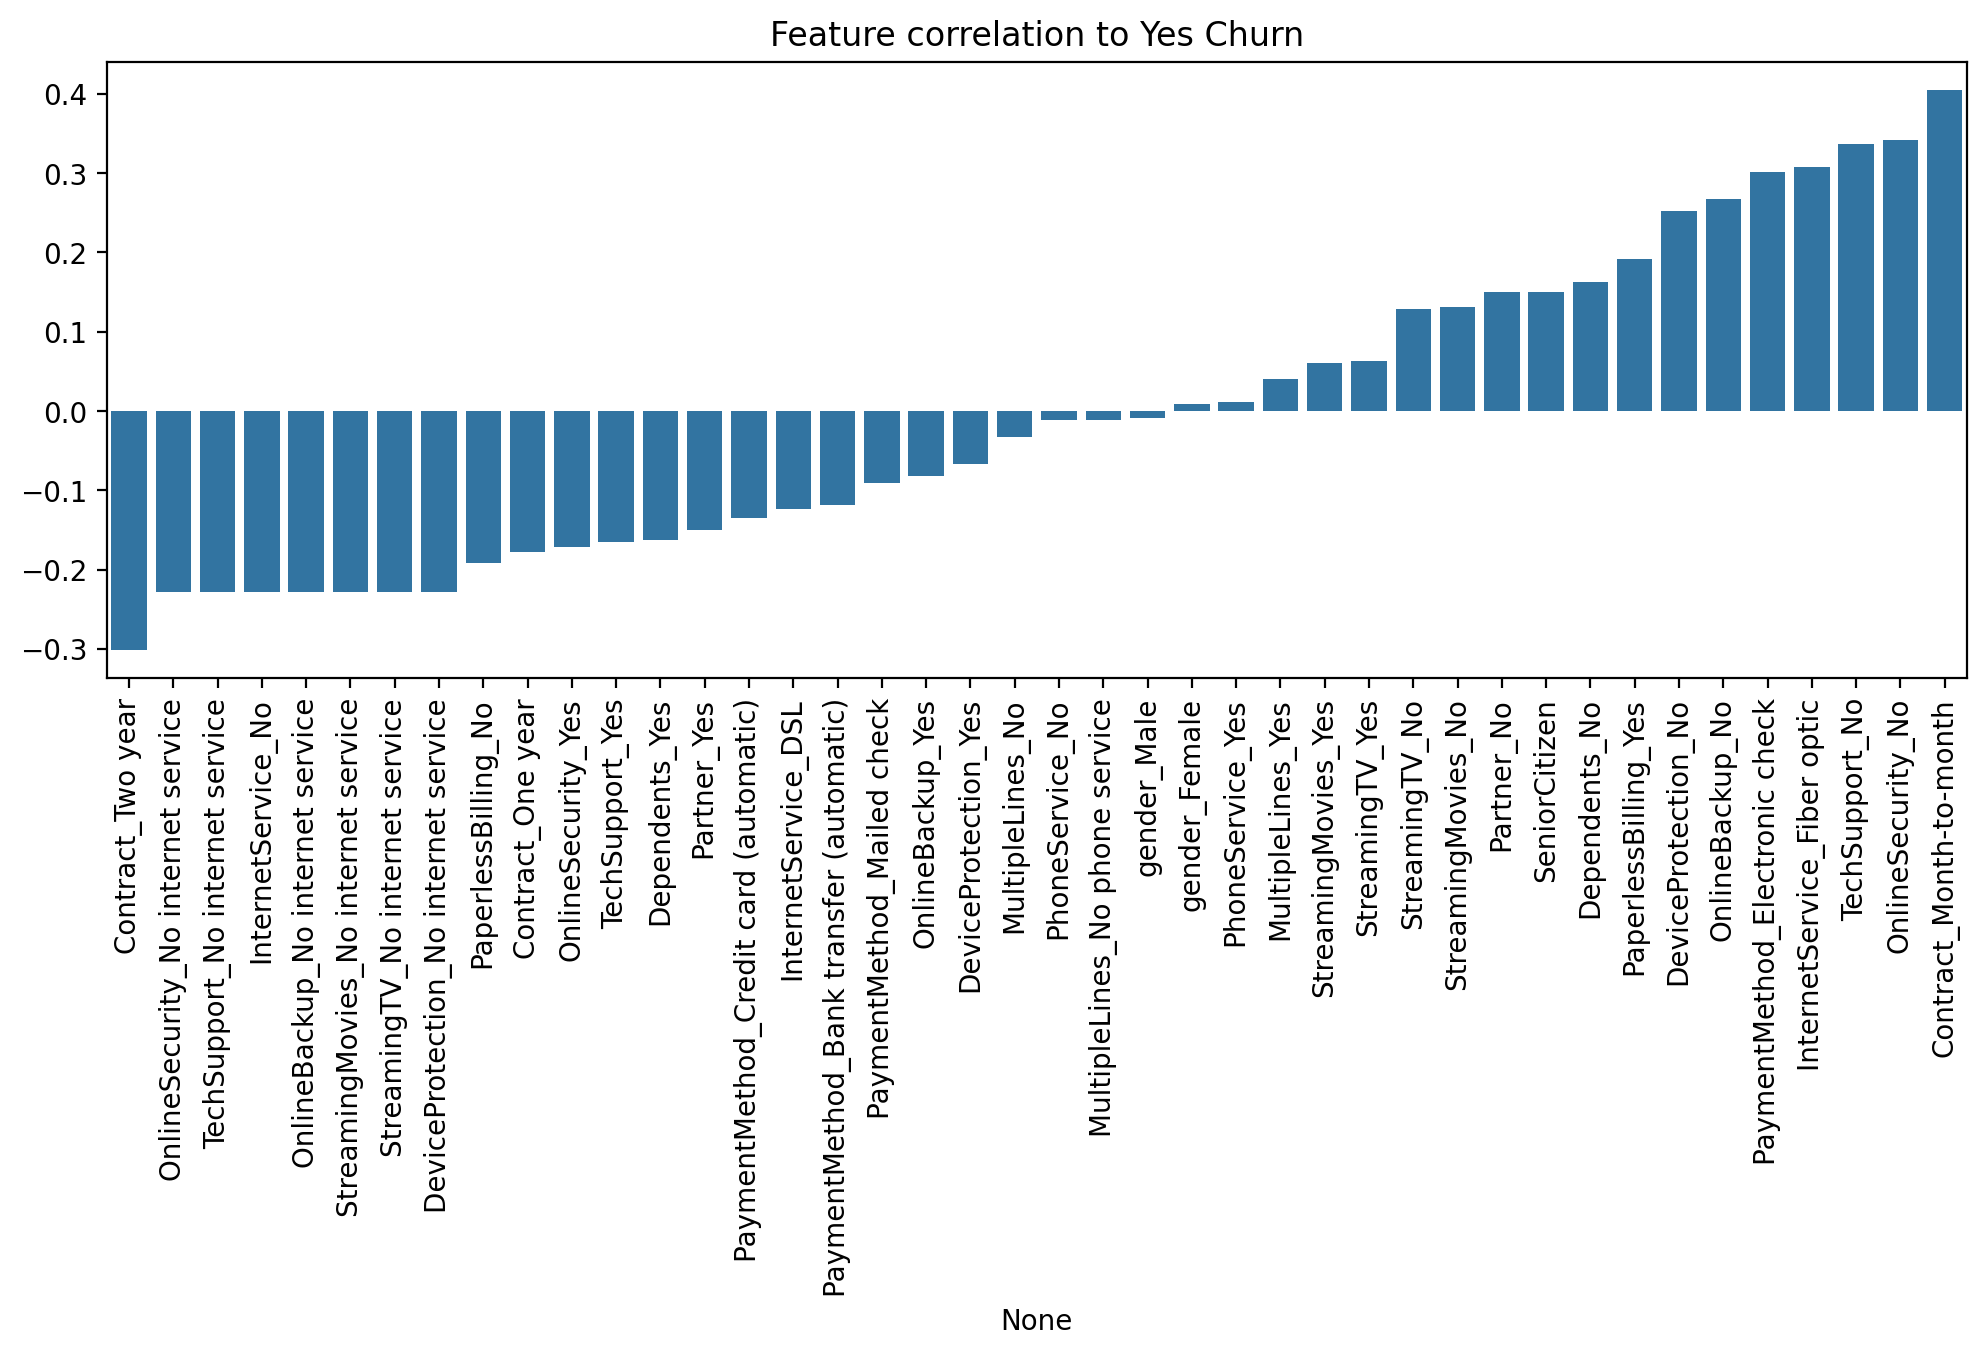

In [36]:
plt.figure(figsize=(12, 4), dpi=200)
sns.barplot(x=corr_df.index, y=corr_df.values)
plt.xticks(rotation=90)
plt.title('Feature correlation to Yes Churn')
plt.show()

Присутствует положительная корреляция ($0.4$) оттока с помесячным контрактом. С двугодичным конрактом наоборот отрицательная корреляция ($-0.3$).

## Часть 3: Анализ оттока

В этих заданиях мы выполним сегментацию абонентов на основе колонки tenure, создавая "когорты" и выполняя сравнение данных между различными когортами.

**Перечислим 3 типа контракта (колонка Contract).**

In [15]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

**Создадим гистограмму с распределением значений колонки tenure - это количество месяцев, сколько времени человек является (или являлся) абонентом компании.**

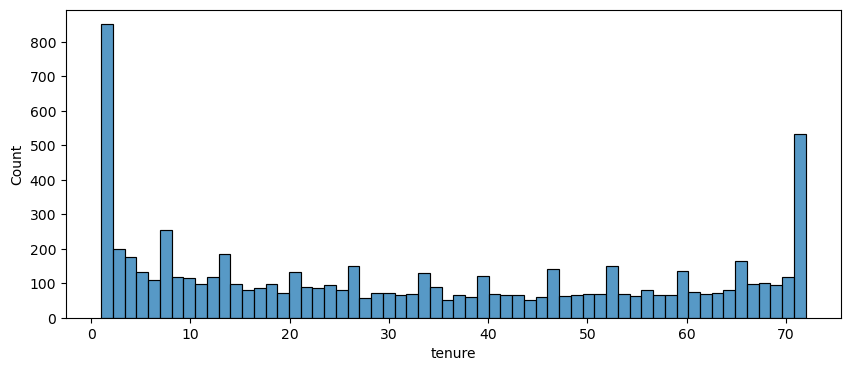

In [16]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='tenure', bins=60);

Заметно, что довольно много людей имеют `tenure` от 1 до 2 месяцев. Второк пиковое значение соотвествует `tenure = 72` месяца. Также на графике периодически появляются всплески, которые могут соотвествовать продлениям годовых/двухлетних контрактов.

**Построим гистограммы для колонки tenure, разбивая данные по двум колонкам - Churn и Contract.**

<Figure size 1280x960 with 0 Axes>

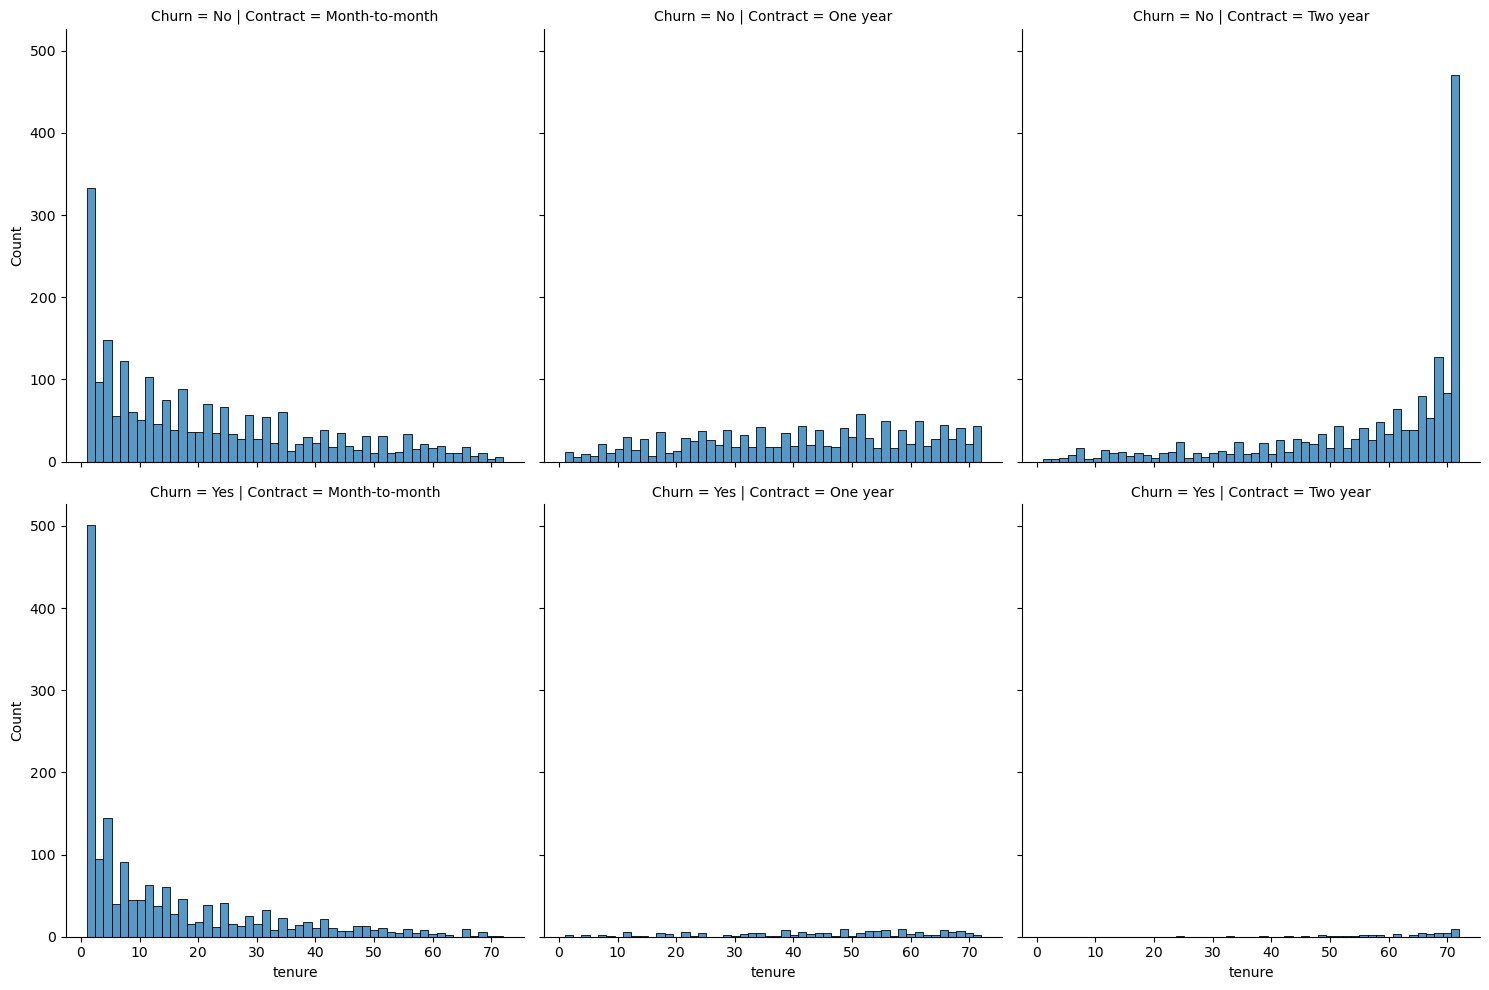

In [17]:
plt.figure(dpi=200)
sns.displot(data=df, x='tenure', row='Churn', col='Contract', bins=50);

По нижним графикам видно, что люди с длительнымии контрактами практически не уходят в отток. В основном от услуг компании отказываются клиенты с контрактами `'month-to'month'`.

Также интересно, что есть клиенты с помесячным тарифом, которые используют его 20 и более месяцев. Скорее всего цены на таком тарифе выше, чем на годовом. Таким людям можно было бы предлагать перейти на более долгие контракты. Да, мы сначала немного потеряем в деньгах, но скорее всего это принесет доход в перспективе, если человек продолжит пользоваться услугами компании.

**Построим график scatterplot для колонок Total Charges и Monthly Charges, раскрашивая график цветами по колонке Churn.**

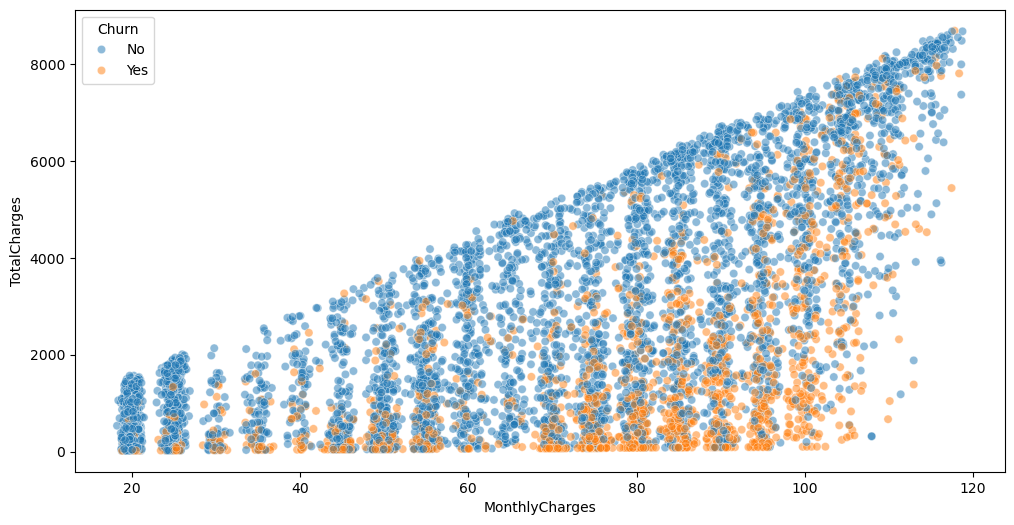

In [18]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.5);

Видна линейная зависимость между месячными платежами и суммарными, что вполне логично. Также по графику видно, что в отток уходят те, у кого больше ежемесячные расходы.

### Создание когорт (сегментов) по колонке Tenure

**Для начала поместим различные значения tenure (1 месяц, 2 месяца, 3 месяца и так далее) в отдельные когорты.**

Для каждого уникального значения колонки tenure в качестве когорты, вычислим процент оттока - это количество тех людей, кто ушел в отток в когорте, как процент от общего количества людей в данной когорте. Вычислим такой процент отдельно для каждой когорты.

In [19]:
df['tenure'].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
38     59
28     57
39     56
44     51
36     50
Name: count, Length: 72, dtype: int64

In [20]:
churn_by_tenure = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='churn_rate')
churn_by_tenure

,tenure,churn_rate
0,1,61.990212
1,2,51.680672
2,3,47.000000
3,4,47.159091
4,5,48.120301
...,...,...
67,68,9.000000
68,69,8.421053
69,70,9.243697
70,71,3.529412


**Используя результаты предыдущего пункта, построим график процента оттока для различных значений tenure.**

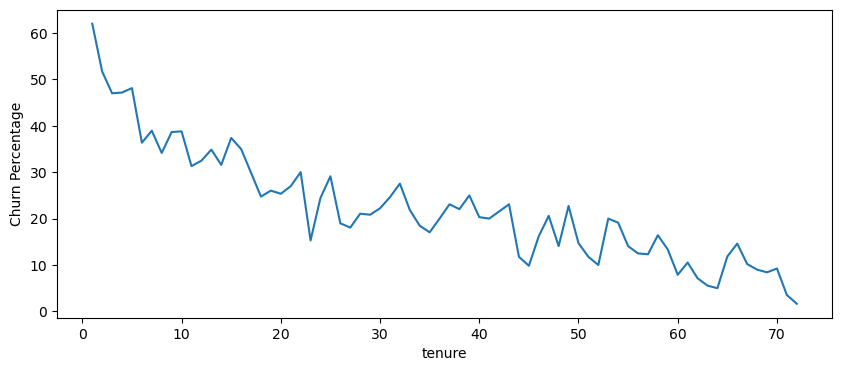

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(churn_by_tenure['tenure'], churn_by_tenure['churn_rate'])
plt.xlabel('tenure')
plt.ylabel('Churn Percentage')
plt.show()

Для `tenure = 1` отток практически 60%, но с увеличением времени пользования услугами компании процент оттока клиентов уменьшается. Это разумно, потому что чем дольше человек пользуется услугами компании, тем вероятнее то, что его/ее все устраивает, и он/она продолжит пользоваться этими услугами.

### Более крупные когорты
**На основе колонки tenure создадим новую колонку с названием "Tenure Cohort", в которой будут следующие 4 категории:**
   * '0-12 месяцев'
   * '12-24 месяцев'
   * '24-48 месяцев'
   * 'Более 48 месяцев'    

In [22]:
def four_categories(x):
    if 0 <= x <= 12:
        return '0-12 Months'
    if 13 <= x <= 24:
        return '12-24 Months'
    if 25 <= x <= 48:
        return '24-48 Months'
    return 'Over 48 Months'

df['Tenure Cohort'] = df['tenure'].apply(four_categories)
df['Tenure Cohort']

0          0-12 Months
1         24-48 Months
2          0-12 Months
3         24-48 Months
4          0-12 Months
             ...      
7027      12-24 Months
7028    Over 48 Months
7029       0-12 Months
7030       0-12 Months
7031    Over 48 Months
Name: Tenure Cohort, Length: 7032, dtype: object

In [23]:
df.groupby('Tenure Cohort').count()['Churn']

Tenure Cohort
0-12 Months       2175
12-24 Months      1024
24-48 Months      1594
Over 48 Months    2239
Name: Churn, dtype: int64

**Построим график scatterplot для Total Charges и Monthly Charges, раскрашивая график разными цветами по колонке "Tenure Cohort".**

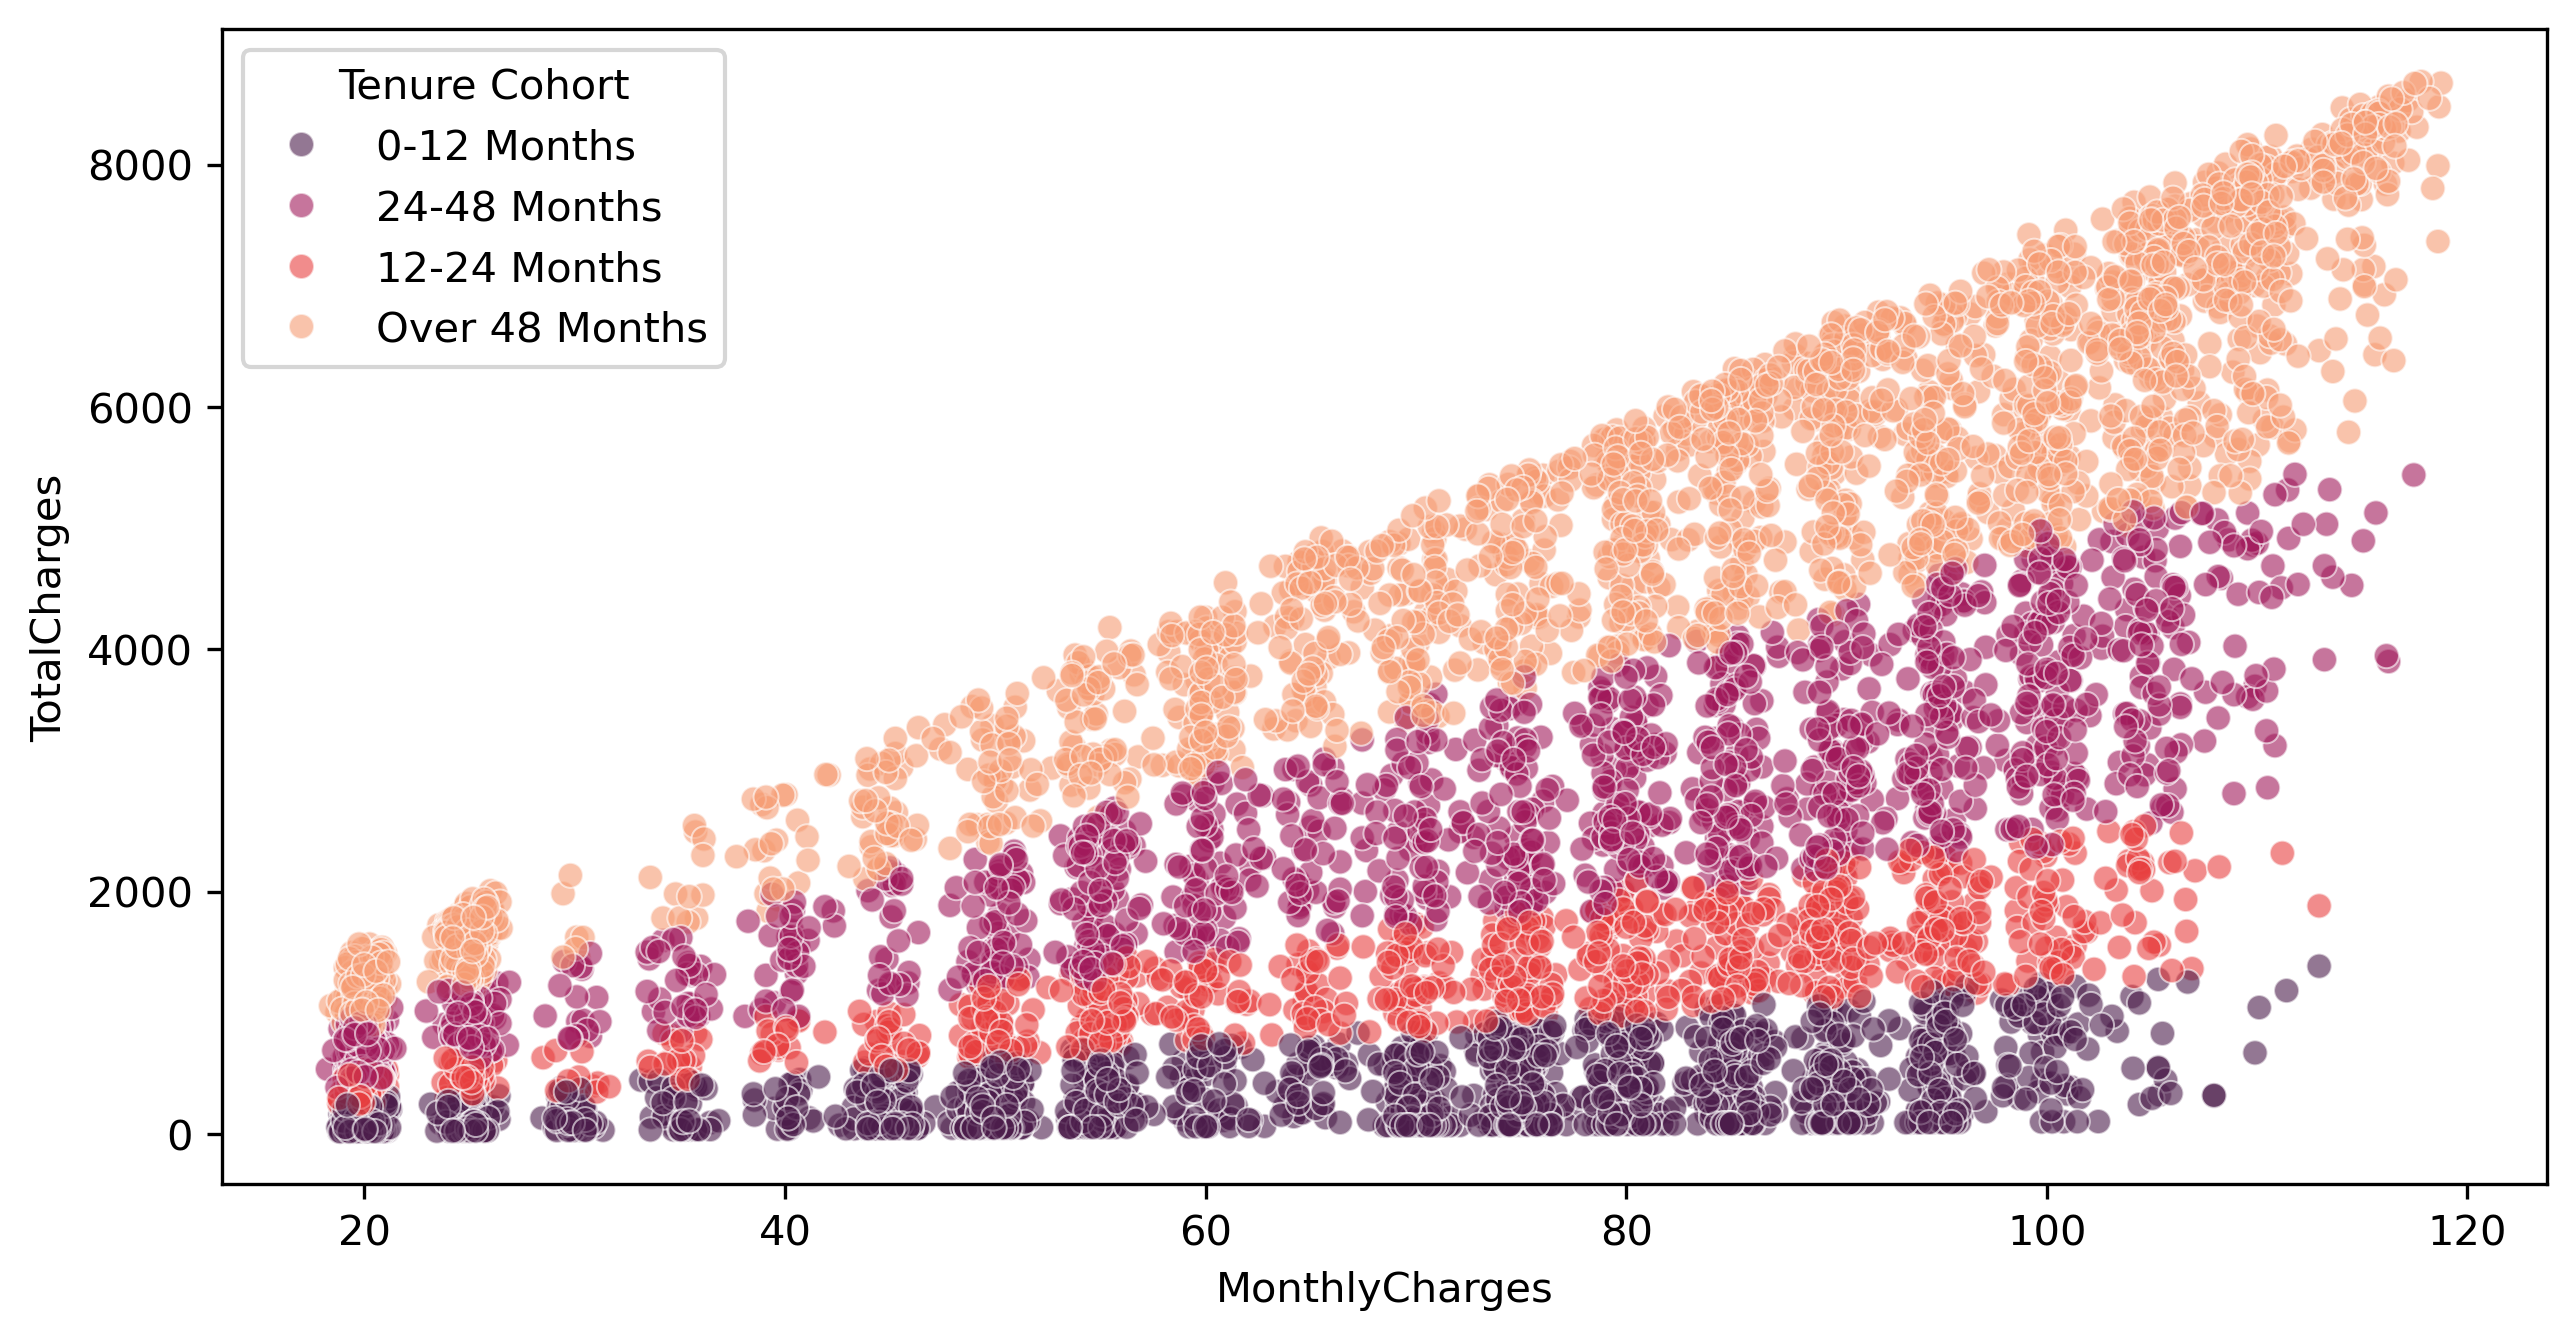

In [24]:
plt.figure(figsize=(10, 5), dpi=300)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Tenure Cohort', palette='rocket', alpha=0.6);

Новые четыре категории `tenure` очень хорошо отделимы друг от друга на графике. Чем больше срок использования, тем больше `TotalCharges`.

**Построим график countplot с количеством ушедших и не ушедших в отток людей в каждой когорте.**

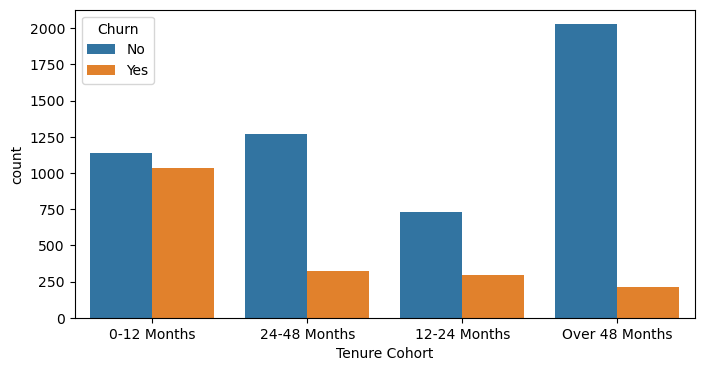

In [25]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Tenure Cohort', hue='Churn');

Те, кто пользуются услугами компании больше 48 месяцев, почти не уход в отток. Однако, если человек имеет длительность обслуживания от 0 до 12 месяцев, вероятность оттока значительно выше.

**Создадим набор графиков CountPlot с количеством людей по различным когортам Tenure Cohort. Для каждого типа контракта создадим отдельный график, и раскрасим эти графики разными цветами по колонке Churn.**

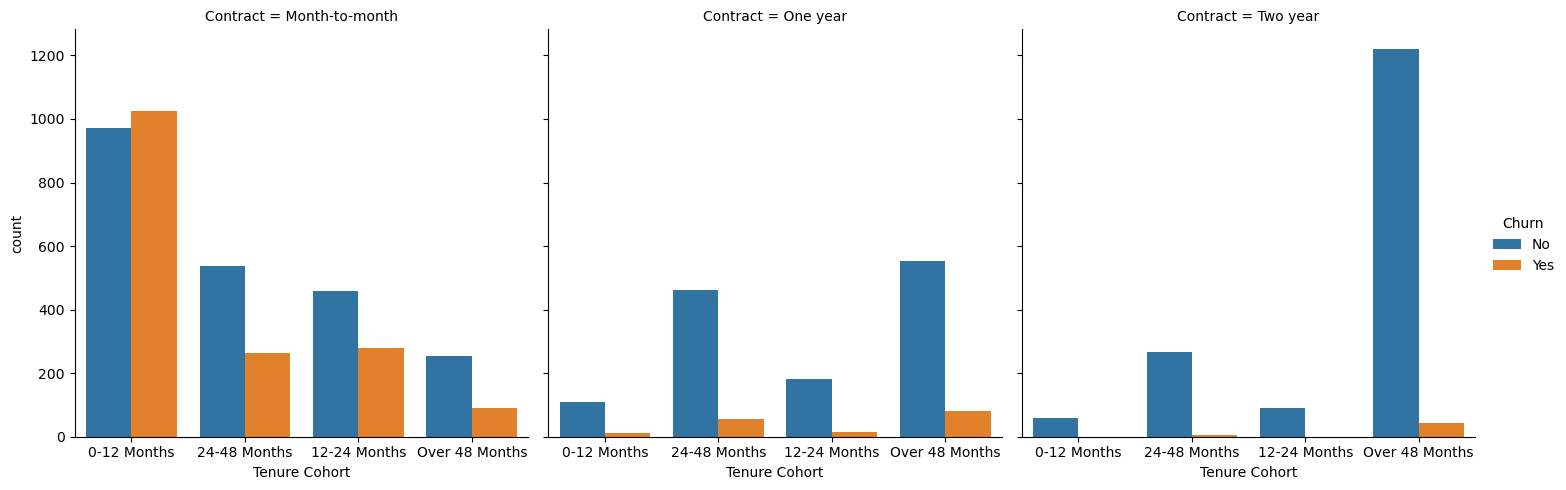

In [26]:
sns.catplot(data=df, x='Tenure Cohort', hue='Churn', col='Contract', kind='count');

Заметно, что люди на однолетнем / двухлетнем конрактах меньше уходят в отток вне зависимости от длительности пользования услугами.

In [ ]:
df = df.drop('Tenure Cohort')

## Часть 4: Предиктивная модель

**Будем исследовать 4 модели на основе деревьев: одно дерево решений, случайный лес, адаптивный бустинг и градиентный бустинг**


Разделим все данные на признаки X и целевую переменную Y. Закодируем категориальные переменные с помощью `OneHotEncoder` из `sklearn`, а также выполним разделение на тренировочную и тестовую выборки с исппользованием `train_test_split`. Удалим признак `'customerID'` из датафрейма, так как он уникальныйй для каждого объекта и не содержит доволнительной информации.

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=101, test_size=0.1)

In [8]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train_cat = enc.fit_transform(X_train[cat_cols])
X_test_cat = enc.transform(X_test[cat_cols])

# преобразуем обратно в датафрейм, чтобы не потерять названия колонок
X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=enc.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=enc.get_feature_names_out(cat_cols),
    index=X_test.index
)

# числовые признаки
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

# итоговые матрицы
X_train_enc = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_enc = pd.concat([X_test_num, X_test_cat], axis=1)

In [9]:
X_train_enc.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2273,1,7,48.20,340.35,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3739,0,7,94.25,669.00,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4480,1,42,74.15,3229.40,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6098,0,1,19.95,19.95,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1498,1,45,102.15,4735.35,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


Я не буду выполнять масштабирование признаков при помощи Standart Scaler, так как в этом эксперименте я буду сравнивать работу алгоритмов машинного обучения, которые основаны на деревьях.

### Одно дерево решений (Decision Tree)

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

model = DecisionTreeClassifier()
model.fit(X_train_enc, y_train)
base_pred = model.predict(X_test_enc)

Оценим результат работы модели:

In [9]:
cm = confusion_matrix(y_test, base_pred)
cm

array([[435, 122],
       [ 73,  74]])

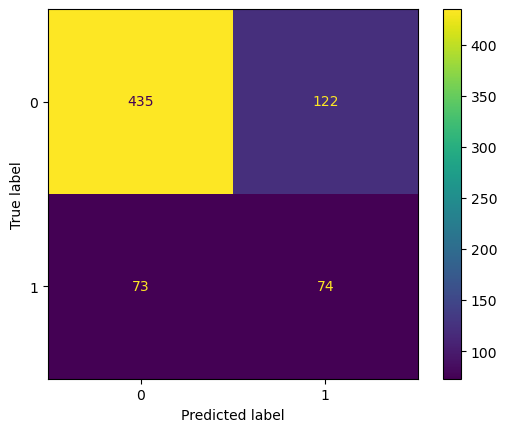

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [11]:
print(classification_report(y_test, base_pred))

              precision    recall  f1-score   support

          No       0.86      0.78      0.82       557
         Yes       0.38      0.50      0.43       147

    accuracy                           0.72       704
   macro avg       0.62      0.64      0.62       704
weighted avg       0.76      0.72      0.74       704



Для дерева решений с гиперпараметрами по умолчанию результат на тестовом датасете получился не очень. Попробуем выполнить **Grid Search** для поиска более оптимальных значений гиперпараметров.

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt'],
    'class_weight': [None, 'balanced']
}

model = DecisionTreeClassifier()

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          verbose=1)

In [11]:
grid_model.fit(X_train_enc, y_train)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10],
                         'max_features': [None, 'sqrt'],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             verbose=1)

In [13]:
grid_model.best_params_

{'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

Посмотрим на важность признаков:

In [25]:
feature_importance = pd.DataFrame(index=X_train_enc.columns, data=grid_model.best_estimator_.feature_importances_, columns=['Feature Importance'])
feature_importance.sort_values('Feature Importance', ascending=False)

,Feature Importance
tenure,0.452239
InternetService_Fiber optic,0.340223
TotalCharges,0.043311
PaymentMethod_Electronic check,0.031130
StreamingTV_No internet service,0.028480
MonthlyCharges,0.027973
Contract_Two year,0.023321
Contract_One year,0.009622
TechSupport_Yes,0.008523
SeniorCitizen,0.008175


Самым важным признаком оказался `tenure` - длительность пользования услугами компании. Многие признаки не участвовали в принятии решений.

Оценим результат работы модели:

In [26]:
pred = grid_model.predict(X_test_enc)

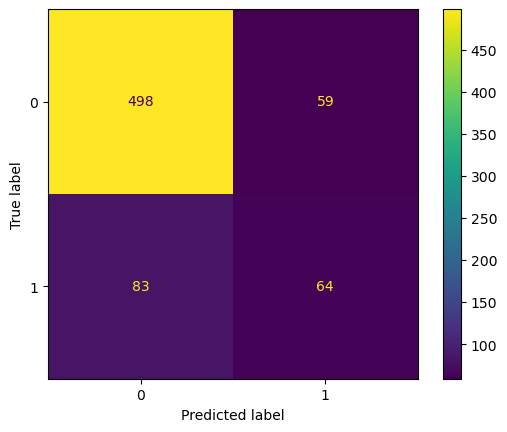

In [27]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [28]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          No       0.86      0.89      0.88       557
         Yes       0.52      0.44      0.47       147

    accuracy                           0.80       704
   macro avg       0.69      0.66      0.67       704
weighted avg       0.79      0.80      0.79       704



Результат стал чуть лучше, но все равно не супер. Думаю, основная проблема в дисбанасе классов таргетной переменной.

Визуализируем обученное дерево, полученное через Grid Search:

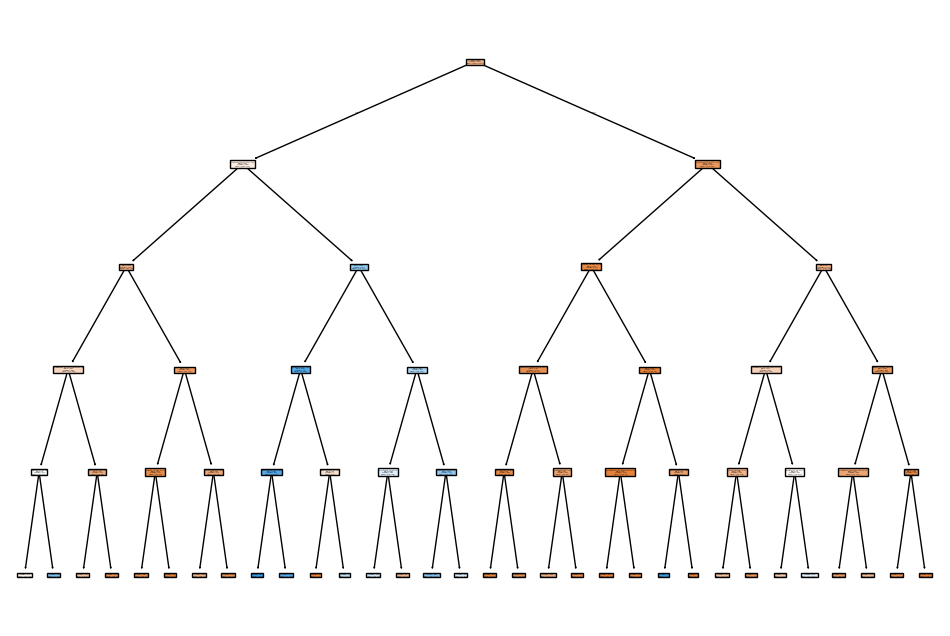

In [31]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(grid_model.best_estimator_, filled=True, feature_names=X_train_enc.columns);

### Случайный лес (Random Forest)


In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=101)
model.fit(X_train_enc, y_train)
preds = model.predict(X_test_enc)

Оценим результат работы модели:

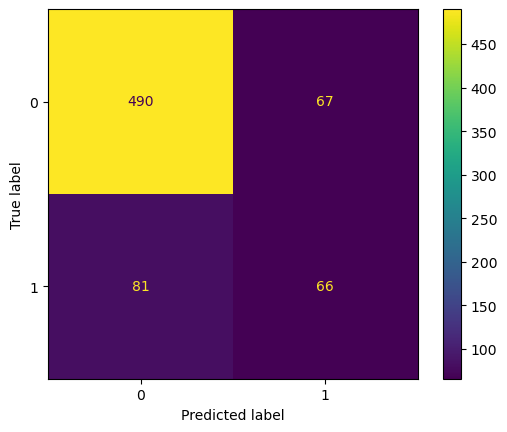

In [35]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [36]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.86      0.88      0.87       557
         Yes       0.50      0.45      0.47       147

    accuracy                           0.79       704
   macro avg       0.68      0.66      0.67       704
weighted avg       0.78      0.79      0.79       704



Попробуем применить поиск по сетке для случайного леса:

In [37]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

model = RandomForestClassifier(random_state=101)

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          verbose=1)

grid_model.fit(X_train_enc, y_train)
preds = grid_model.predict(X_test_enc)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [38]:
grid_model.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [39]:
feature_importance = pd.DataFrame(index=X_train_enc.columns, data=grid_model.best_estimator_.feature_importances_, columns=['Feature Importance'])
feature_importance.sort_values('Feature Importance', ascending=False)

,Feature Importance
tenure,0.191471
TotalCharges,0.160120
MonthlyCharges,0.114260
InternetService_Fiber optic,0.073769
Contract_Two year,0.067868
PaymentMethod_Electronic check,0.062200
Contract_One year,0.035035
TechSupport_Yes,0.032160
OnlineSecurity_Yes,0.027759
PaperlessBilling_Yes,0.022100


Теперь мы используем все признаки из датасета по сравнению с деревьями решений. Также признак `tenure` все еще занимает лидирующее место по важности.

Оценим результат работы модели:

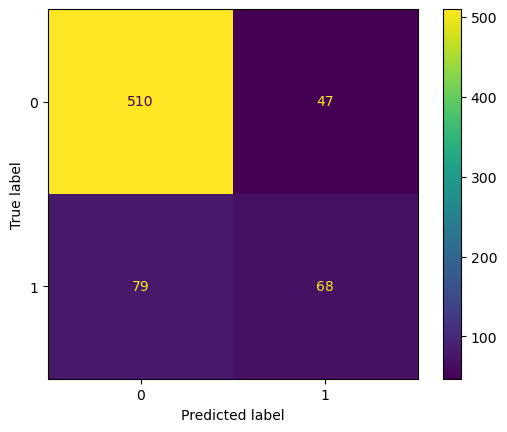

In [40]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [41]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.87      0.92      0.89       557
         Yes       0.59      0.46      0.52       147

    accuracy                           0.82       704
   macro avg       0.73      0.69      0.70       704
weighted avg       0.81      0.82      0.81       704



Результаты классификации стали немного лучше после поиска оптимальных значений гиперпараметров.

### Расширяемые деревья (Boosted Trees)

#### 1. AdaBoost

Тут сразу будем выпеолнять поиск по сетке без тестирования модели с базовыми значениями гиперпараметров.

In [10]:
from sklearn.ensemble import AdaBoostClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.5]
}

base_tree = DecisionTreeClassifier(random_state=42)
model = AdaBoostClassifier(
    estimator=base_tree,
    random_state=101
)

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          verbose=1)

grid_model.fit(X_train_enc, y_train)
preds = grid_model.predict(X_test_enc)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [11]:
grid_model.best_params_

{'learning_rate': 0.5, 'n_estimators': 200}

Оценим результат работы модели:

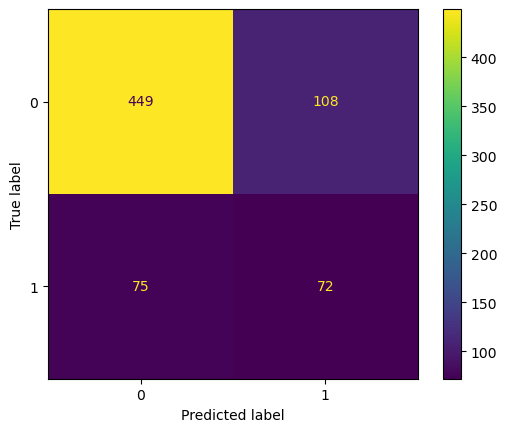

In [13]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [14]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.86      0.81      0.83       557
         Yes       0.40      0.49      0.44       147

    accuracy                           0.74       704
   macro avg       0.63      0.65      0.64       704
weighted avg       0.76      0.74      0.75       704



Результат так себе, модель начала чаще предсказывать ложноположительные значения.

#### 2. Градиентный бустинг

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

model = GradientBoostingClassifier(random_state=101)

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          verbose=1)

grid_model.fit(X_train_enc, y_train)
preds = grid_model.predict(X_test_enc)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [16]:
grid_model.best_params_

{'learning_rate': 0.05, 'n_estimators': 200}

Оценим результат работы модели:

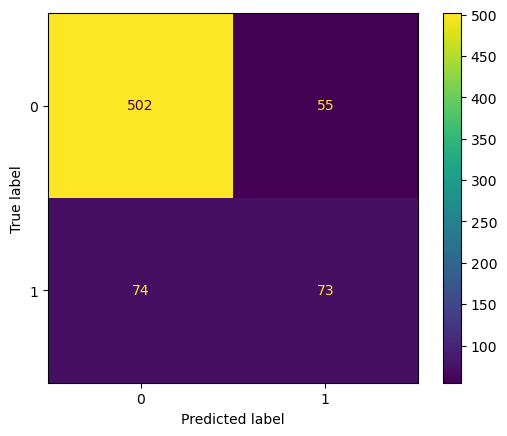

In [18]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [19]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.87      0.90      0.89       557
         Yes       0.57      0.50      0.53       147

    accuracy                           0.82       704
   macro avg       0.72      0.70      0.71       704
weighted avg       0.81      0.82      0.81       704



Качество работы градиентного бустинга оказалось значительно лучше, чем у AdaBoost.

По результатам лучше всего работает модель градиентного бустинга с параметрами `{'learning_rate': 0.05, 'n_estimators': 200}`. На удивление Ada Boost справилась гораздо хуже. Случайный лес и дерево решений показали неплохие результаты с оптимальными значениями гиперпараметров.